### **Import Required Libraries**

In [1]:
# for data manipulation
import pandas as pd

# for numerical computations
import numpy as np

# for data visualization
import seaborn as sns

# for skewness calculation
from scipy.stats import skew

# display plots inline
%matplotlib inline

# for plotting graphs
import matplotlib.pyplot as plt

# apply ggplot style for cleaner visuals
plt.style.use("ggplot")

# set default figure size for plots
plt.rcParams["figure.figsize"] = (12, 8)

### **Load the Dataset**

In [2]:
# dataset contains sales generated from advertising spend across tv, radio, and newspaper channels

# load dataset into dataframe
advert = pd.read_csv("Advertising.csv")

# display first 5 rows
advert.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### **Dataset Structure Check**

In [3]:
# display dataset structure with non-null counts and data types
advert.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### **Relationship Between Features and Target**

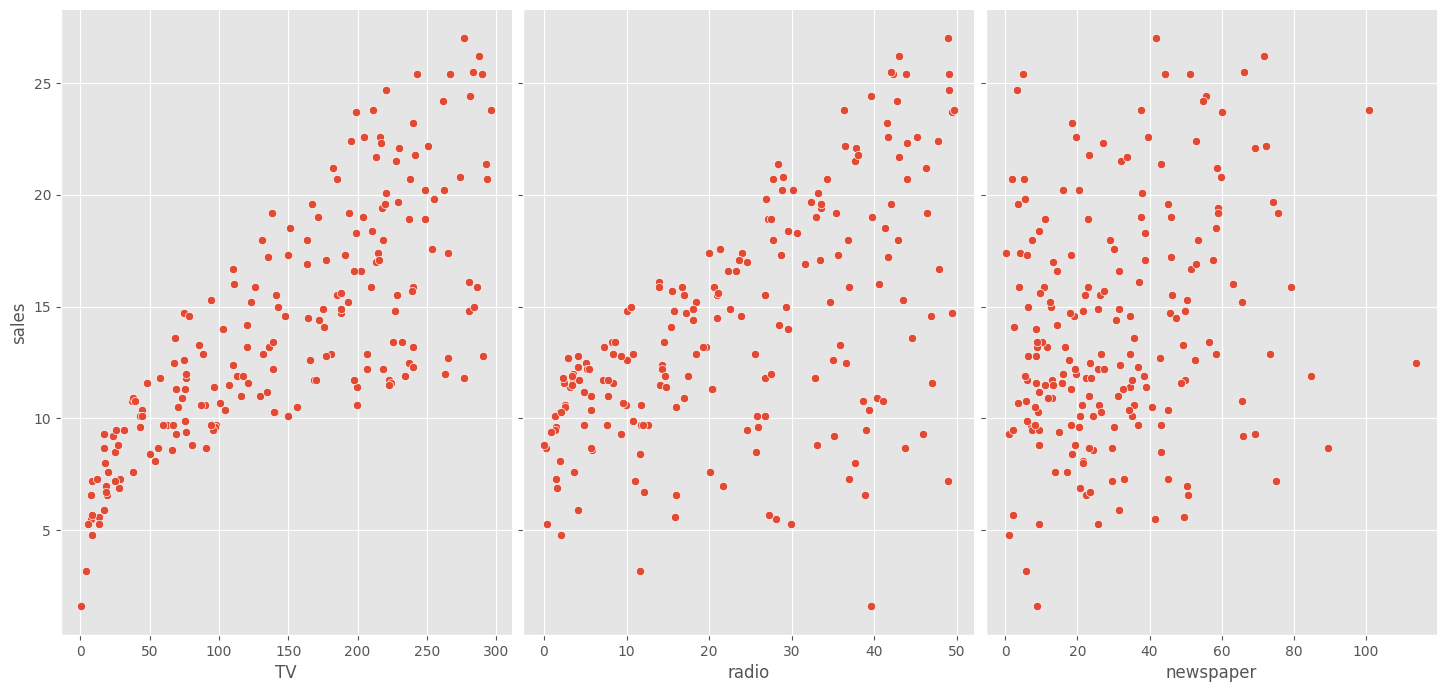

In [4]:
# visualize relationship between advertising channels and sales
sns.pairplot(
    advert,
    x_vars=["TV", "radio", "newspaper"],
    y_vars="sales",
    height=7,
    aspect=0.7
)

## **Multiple Linear Regression - Estimate Coefficients**

In [5]:
# train a linear regression model to predict sales using advertising spend channels

from sklearn.linear_model import LinearRegression

# define input features
feature_cols = ["TV", "radio", "newspaper"]
X = advert[feature_cols]

# define target variable
y = advert["sales"]

# create linear regression model
lr_model = LinearRegression()

# train the model on the dataset
lr_model.fit(X, y)

# display model intercept
print("Intercept:", lr_model.intercept_)

# display coefficients for each feature
print("Coefficients:", lr_model.coef_)

Intercept: 2.938889369459412
Coefficients: [ 0.04576465  0.18853002 -0.00103749]


### **Map Features with Their Coefficients**

In [6]:
# pair feature names with learned coefficients
coef_summary = list(zip(feature_cols, lr_model.coef_))

# display feature-wise coefficient values
coef_summary

[('TV', np.float64(0.0457646454553976)),
 ('radio', np.float64(0.18853001691820448)),
 ('newspaper', np.float64(-0.0010374930424763285))]

### **Correlation Heatmap**

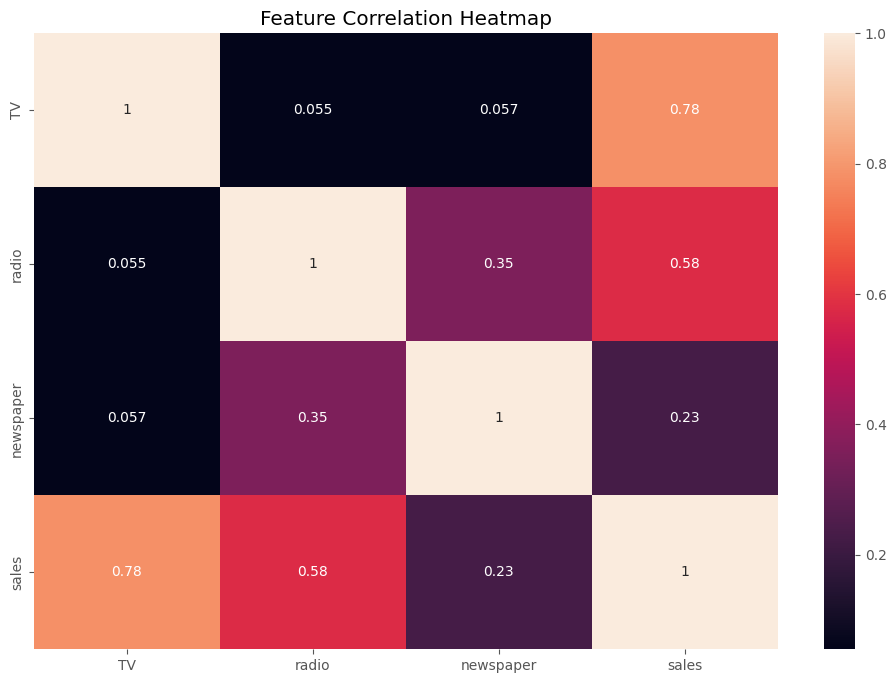

In [7]:
# visualize correlation among features and sales
# also helps identify multicollinearity among input features
sns.heatmap(advert.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### **Feature Selection**

In [8]:
# train model using only tv and radio to compare performance

from sklearn.metrics import r2_score

# train regression model with selected features
selected_model = LinearRegression().fit(X[["TV", "radio"]], y)

# predict sales
selected_preds = selected_model.predict(X[["TV", "radio"]])

# evaluate model performance using r² score
print("R² Score:", r2_score(y, selected_preds))

R² Score: 0.8971942610828957


In [9]:
# train linear regression model using all three advertising channels
full_model = LinearRegression().fit(
    X[["TV", "radio", "newspaper"]],
    y
)

# predict sales using full feature set
full_preds = full_model.predict(
    X[["TV", "radio", "newspaper"]]
)

# evaluate model performance using r² score
print("R² Score:", r2_score(y, full_preds))

R² Score: 0.8972106381789522


### **Model Evaluation with Train-Test Split**

In [10]:
# split data, train model, and evaluate on test data

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# define features and target
X = advert[["TV", "radio", "newspaper"]]
y = advert["sales"]

# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1
)

# train model on training data
test_model = LinearRegression()
test_model.fit(X_train, y_train)

# generate predictions on test data
test_preds = test_model.predict(X_test)

# evaluate prediction error using rmse
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))

# evaluate explained variance using r² score
print("R² Score:", r2_score(y_test, test_preds))

RMSE: 1.404651423032895
R² Score: 0.9156213613792232


### **Final Model Evaluation on Train-Test Split**

In [11]:
# select tv and radio as predictors

X = advert[["TV", "radio"]]
y = advert["sales"]

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=1
)

# train linear regression model
final_model = LinearRegression()
final_model.fit(X_train, y_train)

# predict on unseen test data
test_preds = final_model.predict(X_test)

# evaluate model performance using rmse and r² score
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("R² Score:", r2_score(y_test, test_preds))

RMSE: 1.3879034699382888
R² Score: 0.9176214942248907


### **Prediction Error Plot**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


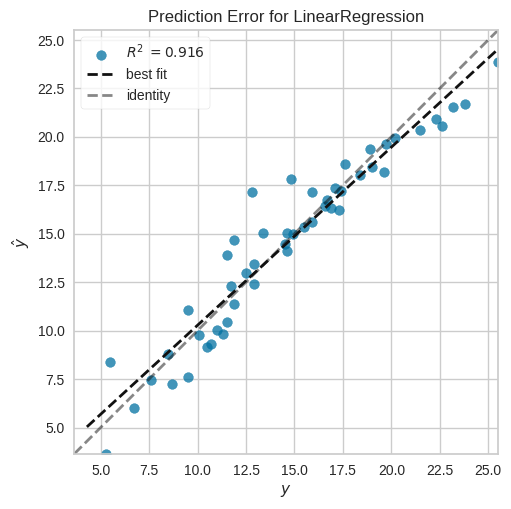

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [12]:
# import prediction error visualizer
from yellowbrick.regressor import PredictionError

# define feature set used in test model
X_vis = advert[["TV", "radio", "newspaper"]]
y_vis = advert["sales"]

# split data using same random state
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    random_state=1
)

# create prediction error visualizer using trained model
visualizer = PredictionError(test_model)

# fit visualizer on training data
visualizer.fit(X_train_vis, y_train_vis)

# evaluate model on test data
visualizer.score(X_test_vis, y_test_vis)

# display prediction error plot
visualizer.show()

### **Residual Plot**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


0.9156213613792232

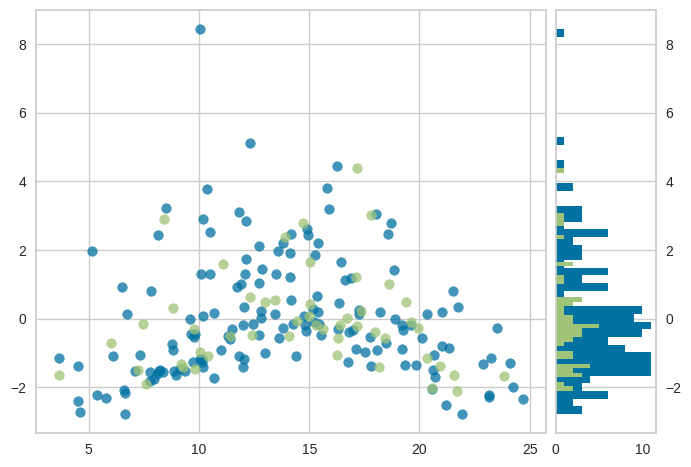

In [13]:
from yellowbrick.regressor import ResidualsPlot

# define feature set used in test model
X_vis = advert[["TV", "radio", "newspaper"]]
y_vis = advert["sales"]

# split data using same random state
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    random_state=1
)

# create residuals visualizer using trained model
visualizer = ResidualsPlot(test_model)

# fit visualizer on training data
visualizer.fit(X_train_vis, y_train_vis)

# evaluate residuals on test data
visualizer.score(X_test_vis, y_test_vis)

### **Interaction Effect (Synergy)**

In [14]:
# capture combined effect of tv and radio advertising on sales

# create interaction feature
advert["interaction"] = advert["TV"] * advert["radio"]

# define predictors including interaction term
X = advert[["TV", "radio", "interaction"]]
y = advert["sales"]

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1
)

# train linear regression model
interaction_model = LinearRegression()
interaction_model.fit(X_train, y_train)

# generate predictions on test data
interaction_preds = interaction_model.predict(X_test)

# evaluate model performance using rmse and r² score
print("RMSE:", np.sqrt(mean_squared_error(y_test, interaction_preds)))
print("R² Score:", r2_score(y_test, interaction_preds))

RMSE: 0.7011871137164328
R² Score: 0.978973681468126


### **Prediction Error Plot: Interaction Model**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


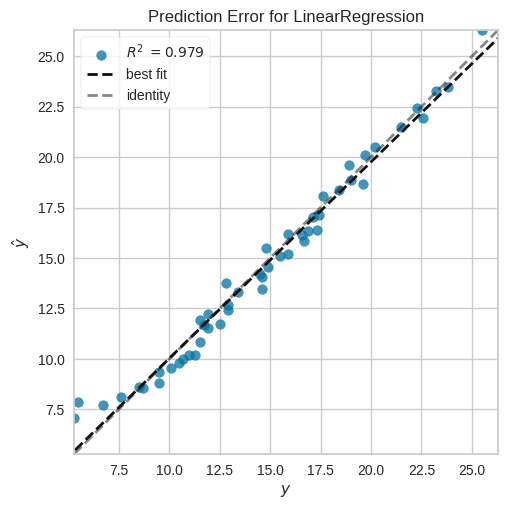

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [15]:
# compare actual vs predicted sales for interaction model

from yellowbrick.regressor import PredictionError

# create prediction error visualizer for interaction model
visualizer = PredictionError(interaction_model)

# fit visualizer on training data
visualizer.fit(X_train, y_train)

# evaluate model on test data
visualizer.score(X_test, y_test)

# display prediction error plot
visualizer.show()